In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/drive/MyDrive/nhanes_bmi.csv')
print(df.head())
is_nan = df.isna()
print("Missing Values")
print(np.sum(is_nan))

   Unnamed: 0    BMI  School_meal  age  ChildSex  black  mexam  pir200_plus  \
0           1  15.18            0    6         0      0      0            1   
1           2  17.93            0    6         1      0      1            0   
2           3  15.15            1    5         1      0      1            0   
3           4  15.69            1   11         0      0      0            0   
4           5  37.40            0   14         0      0      1            0   

   WIC  Food_Stamp  fsdchbi  AnyIns  RefSex  RefAge  
0    0           0        0       1       1      51  
1    1           0        1       1       1      27  
2    0           0        0       0       0      24  
3    0           0        0       1       1      44  
4    0           0        0       0       0      48  
Missing Values
Unnamed: 0     0
BMI            0
School_meal    0
age            0
ChildSex       0
black          0
mexam          0
pir200_plus    0
WIC            0
Food_Stamp     0
fsdchbi        0

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


In [ ]:
group_sizes = df.groupby('School_meal').size()
print(group_sizes)

School_meal
0    1046
1    1284
dtype: int64


In [ ]:
excluded_cols = ['Unnamed: 0', 'School_meal']
covariate_cols = [col for col in df.columns if col not in excluded_cols]
summary_stats = df.groupby('School_meal')[covariate_cols].agg(['mean', 'std'])
print(summary_stats)



                   BMI                  age            ChildSex            \
                  mean       std       mean       std      mean       std   
School_meal                                                                 
0            19.816205  5.369314   9.852772  4.437695  0.524857  0.499621   
1            20.350109  5.458778  10.073209  3.512268  0.511682  0.500058   

                black               mexam            ... Food_Stamp            \
                 mean       std      mean       std  ...       mean       std   
School_meal                                          ...                        
0            0.198853  0.399328  0.177820  0.382544  ...   0.116635  0.321138   
1            0.308411  0.462017  0.327882  0.469624  ...   0.440810  0.496678   

              fsdchbi              AnyIns              RefSex            \
                 mean       std      mean       std      mean       std   
School_meal                                               

In [ ]:
#DiM estimator
mean_treatment = summary_stats.loc[1, ('BMI', 'mean')]
mean_control = summary_stats.loc[0, ('BMI', 'mean')]
difference_in_means = mean_treatment - mean_control

n_treatment = group_sizes.loc[1]
n_control = group_sizes.loc[0]
std_treatment = summary_stats.loc[1, ('BMI', 'std')]
std_control = summary_stats.loc[0, ('BMI', 'std')]
SE = np.sqrt(std_treatment ** 2 / n_treatment + std_control ** 2 / n_control)

print("Difference in Means (Treatment - Control) for Covariates:")
print(difference_in_means)
print("t-statistic:")
print(difference_in_means / SE)

Difference in Means (Treatment - Control) for Covariates:
0.5339044453577806
t-statistic:
2.3695396119467573


## Assessing overlap in covariate distrbutions

In [ ]:
covariates_for_diff = [col for col in covariate_cols if col != 'BMI']

mean_treatment = summary_stats.loc[1, (covariates_for_diff, 'mean')]
mean_control = summary_stats.loc[0, (covariates_for_diff, 'mean')]

difference_in_means = mean_treatment - mean_control

std_treatment_covariates = summary_stats.loc[1, (covariates_for_diff, 'std')]
std_control_covariates = summary_stats.loc[0, (covariates_for_diff, 'std')]

# Calculate the denominator for the normalized difference as per the user's formula
# sqrt((S_T^2 + S_C^2) / 2)
denominator_normalized_diff = np.sqrt((std_treatment_covariates**2 + std_control_covariates**2) / 2)

# Calculate the normalized difference by dividing the difference in means by the denominator
# Drop the second level of the MultiIndex for correct alignment during division
normalized_difference = difference_in_means.droplevel(1) / denominator_normalized_diff.droplevel(1)

print("Difference in Means (Treatment - Control) for Covariates:")
print(difference_in_means)
print("\nNormalized Differences (Delta_CT) for Covariates:")
print(normalized_difference)

Difference in Means (Treatment - Control) for Covariates:
age          mean    0.220436
ChildSex     mean   -0.013174
black        mean    0.109558
mexam        mean    0.150061
pir200_plus  mean   -0.414683
WIC          mean    0.145509
Food_Stamp   mean    0.324175
fsdchbi      mean    0.177362
AnyIns       mean   -0.048227
RefSex       mean   -0.108787
RefAge       mean   -1.735228
dtype: float64

Normalized Differences (Delta_CT) for Covariates:
age            0.055084
ChildSex      -0.026357
black          0.253718
mexam          0.350362
pir200_plus   -0.915672
WIC            0.383255
Food_Stamp     0.775128
fsdchbi        0.426368
AnyIns        -0.140164
RefSex        -0.219963
RefAge        -0.173098
dtype: float64


In [ ]:

df_control = df[df['School_meal'] == 0][covariates_for_diff]
covariance_matrix_control = df_control.cov()
df_treatment = df[df['School_meal'] == 1][covariates_for_diff]
covariance_matrix_treatment= df_treatment.cov()

pooled_covariance_matrix = (covariance_matrix_control + covariance_matrix_treatment) / 2

inverted_pooled_covariance_matrix = np.linalg.inv(pooled_covariance_matrix)

# Recalculate difference_in_means for all covariates_for_diff
mean_treatment_covariates = summary_stats.loc[1, (covariates_for_diff, 'mean')]
mean_control_covariates = summary_stats.loc[0, (covariates_for_diff, 'mean')]
difference_in_means = mean_treatment_covariates - mean_control_covariates

diff_means_array = difference_in_means.values.reshape(-1, 1)

multivariate_normalized_difference = np.sqrt(diff_means_array.T @ inverted_pooled_covariance_matrix @ diff_means_array)

print("Multivariate Normalized Difference (Mahalanobis Distance Squared):")
print(multivariate_normalized_difference[0][0])

Multivariate Normalized Difference (Mahalanobis Distance Squared):
1.2074589933248483


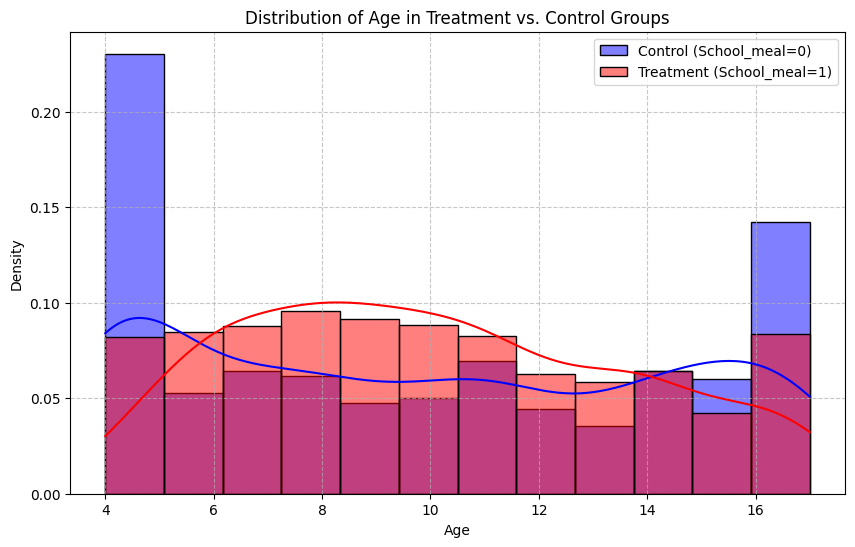

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter age data for control and treatment groups
age_control = df[df['School_meal'] == 0]['age']
age_treatment = df[df['School_meal'] == 1]['age']

plt.figure(figsize=(10, 6))

# Plot overlapping histograms
sns.histplot(age_control, color='blue', label='Control (School_meal=0)', kde=True, stat='density', alpha=0.5)
sns.histplot(age_treatment, color='red', label='Treatment (School_meal=1)', kde=True, stat='density', alpha=0.5)

plt.title('Distribution of Age in Treatment vs. Control Groups')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
conditional_probabilities = df.groupby('School_meal')[['pir200_plus', 'Food_Stamp']].mean()
print("Conditional Probability of pir200_plus and Food_Stamp given School_meal:")
print(conditional_probabilities)

Conditional Probability of pir200_plus and Food_Stamp given School_meal:
             pir200_plus  Food_Stamp
School_meal                         
0               0.661568    0.116635
1               0.246885    0.440810


In [ ]:
conditional_probabilities_school_meal = df.groupby(['pir200_plus', 'Food_Stamp'])['School_meal'].mean()
print("Conditional Probability of School_meal=1 given pir200_plus and Food_Stamp:")
print(conditional_probabilities_school_meal)

Conditional Probability of School_meal=1 given pir200_plus and Food_Stamp:
pir200_plus  Food_Stamp
0            0             0.652482
             1             0.823052
1            0             0.275347
             1             0.819444
Name: School_meal, dtype: float64


## Stratification Discrete

In [ ]:
df['stratum'] = df['pir200_plus'].astype(str) + '_' + df['Food_Stamp'].astype(str)

In [ ]:
stratum_group_sizes = df.groupby(['stratum', 'School_meal']).size()
print("Stratum-wise group sizes (treatment and control):")
print(stratum_group_sizes)

Stratum-wise group sizes (treatment and control):
stratum  School_meal
0_0      0              245
         1              460
0_1      0              109
         1              507
1_0      0              679
         1              258
1_1      0               13
         1               59
dtype: int64


In [ ]:
stratum_bmi_means = df.groupby(['stratum', 'School_meal'])['BMI'].mean()
print("Stratum-wise mean BMI (treatment and control):\n", stratum_bmi_means)

stratum_bmi_means_unstacked = stratum_bmi_means.unstack()

stratum_effects = stratum_bmi_means_unstacked[1] - stratum_bmi_means_unstacked[0]
print("\nStratum-specific treatment effects (difference in means):\n", stratum_effects)

Stratum-wise mean BMI (treatment and control):
 stratum  School_meal
0_0      0              19.866939
         1              20.670391
0_1      0              19.644312
         1              19.843708
1_0      0              19.815243
         1              20.925233
1_1      0              20.351538
         1              19.689661
Name: BMI, dtype: float64

Stratum-specific treatment effects (difference in means):
 stratum
0_0    0.803453
0_1    0.199396
1_0    1.109990
1_1   -0.661877
dtype: float64


In [ ]:
stratum_sizes = df.groupby('stratum').size()
print("Total observations per stratum:\n", stratum_sizes)

total_observations = df.shape[0]
stratum_proportions = stratum_sizes / total_observations
print("\nProportion of total observations per stratum:\n", stratum_proportions)

overall_ate = (stratum_proportions * stratum_effects).sum()
print("\nOverall Average Treatment Effect (ATE):", overall_ate)

Total observations per stratum:
 stratum
0_0    705
0_1    616
1_0    937
1_1     72
dtype: int64

Proportion of total observations per stratum:
 stratum
0_0    0.302575
0_1    0.264378
1_0    0.402146
1_1    0.030901
dtype: float64

Overall Average Treatment Effect (ATE): 0.7217455379087994


In [ ]:
stratum_bmi_variances = df.groupby(['stratum', 'School_meal'])['BMI'].var()
stratum_bmi_variances_unstacked = stratum_bmi_variances.unstack()

stratum_group_sizes_unstacked = stratum_group_sizes.unstack()


# Calculate the variance of the difference in means for each stratum
# Var(diff) = Var(mean_T) + Var(mean_C) = Var_T/n_T + Var_C/n_C
stratum_variance_of_difference = (stratum_bmi_variances_unstacked[1] / stratum_group_sizes_unstacked[1]) + \
                                 (stratum_bmi_variances_unstacked[0] / stratum_group_sizes_unstacked[0])

# Calculate the standard error of the difference in means for each stratum
stratum_se_of_difference = np.sqrt(stratum_variance_of_difference)

In [ ]:
overall_variance = (stratum_proportions**2 * stratum_variance_of_difference).sum()
overall_variance  += (stratum_proportions  * (stratum_effects  - overall_ate) ** 2).sum()
overall_se = np.sqrt(overall_variance)

print("Overall Variance of Stratified Estimator:", overall_variance)
print("Overall Standard Error of Stratified Estimator:", overall_se)
print("t-statistics: ", overall_ate / overall_se)

Overall Variance of Stratified Estimator: 0.2649550114010041
Overall Standard Error of Stratified Estimator: 0.5147378084044382
t-statistics:  1.4021615007182682


## Estimate propensity score

### Step 1: Start from basic covariates

In [ ]:
import statsmodels.api as sm

# Define the dependent variable (treatment assignment)
y = df['School_meal']


y = df['School_meal']
X_initial = df[['pir200_plus', 'Food_Stamp']]
X_initial = sm.add_constant(X_initial)

initial_logit_model = sm.Logit(y, X_initial)
initial_logit_result = initial_logit_model.fit(disp=0)

# Calculate the propensity scores
propensity_scores = initial_logit_result.predict(X_initial)

print("Logistic Regression Model Summary:")
print(initial_logit_result.summary())

print("\nFirst 5 Propensity Scores:")
print(propensity_scores.head())

Logistic Regression Model Summary:
                           Logit Regression Results                           
Dep. Variable:            School_meal   No. Observations:                 2330
Model:                          Logit   Df Residuals:                     2327
Method:                           MLE   Df Model:                            2
Date:                Wed, 04 Mar 2026   Pseudo R-squ.:                  0.1634
Time:                        06:31:47   Log-Likelihood:                -1340.9
converged:                       True   LL-Null:                       -1602.9
Covariance Type:            nonrobust   LLR p-value:                1.686e-114
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.5252      0.075      7.006      0.000       0.378       0.672
pir200_plus    -1.4037      0.098    -14.275      0.000      -1.596      -1.211
Food_Stamp   

### Step 2: Add more covariates

In [ ]:
import statsmodels.api as sm


all_covariates = [col for col in df.columns if col not in ['Unnamed: 0', 'School_meal', 'BMI','stratum']]
selected_covariates = ['pir200_plus', 'Food_Stamp']
remaining_covariates = [cov for cov in all_covariates if cov not in selected_covariates]
print(remaining_covariates)

CL = 1
current_log_likelihood = initial_logit_result.llf
print(current_log_likelihood)


# Keep track of the best covariates found so far
# selected_covariates is already initialized from previous step

# Loop for forward stepwise selection

print("\n--- Starting Forward Stepwise Selection ---")
while True:
    best_lr_stat = 0
    best_covariate_to_add = None

    for candidate_covariate in remaining_covariates:
        temp_covariates = selected_covariates + [candidate_covariate]
        X_temp = df[temp_covariates]
        X_temp = sm.add_constant(X_temp)

        temp_logit_model = sm.Logit(y, X_temp)
        temp_logit_result = temp_logit_model.fit(disp=0)

        temp_log_likelihood = temp_logit_result.llf

        # Calculate Likelihood Ratio statistic: LR = -2 * (LL_restricted - LL_full)
        # Here, LL_restricted is current_log_likelihood and LL_full is temp_log_likelihood
        lr_stat = -2 * (current_log_likelihood - temp_log_likelihood)

        print(f"  Testing {candidate_covariate}: LR statistic = {lr_stat:.2f}")

        if lr_stat > best_lr_stat:
            best_lr_stat = lr_stat
            best_covariate_to_add = candidate_covariate

    if best_covariate_to_add is not None and best_lr_stat > CL:
        selected_covariates.append(best_covariate_to_add)
        remaining_covariates.remove(best_covariate_to_add)

        # Update current_log_likelihood to the new best model's log-likelihood
        X_new_best = df[selected_covariates]
        X_new_best = sm.add_constant(X_new_best)
        new_best_logit_model = sm.Logit(y, X_new_best)
        new_best_logit_result = new_best_logit_model.fit(disp=0)
        current_log_likelihood = new_best_logit_result.llf

        print(f"  Added '{best_covariate_to_add}' to selected covariates. New LR stat: {best_lr_stat:.2f} (>{CL}).")
        print(f"  Current selected covariates: {selected_covariates}")
        print(f"  Updated Log-Likelihood: {current_log_likelihood:.2f}")
        print("\n")
    else:
        print(f"\nNo more covariates to add based on CL = {CL}.")
        break

print("\nFinal selected covariates:", selected_covariates)
final_X = df[selected_covariates]
final_X = sm.add_constant(final_X)
final_logit_model = sm.Logit(y, final_X)
final_logit_result = final_logit_model.fit(disp=0)
print("\nFinal Logistic Regression Model Summary:")
print(final_logit_result.summary())

['age', 'ChildSex', 'black', 'mexam', 'WIC', 'fsdchbi', 'AnyIns', 'RefSex', 'RefAge']
-1340.8840229239527

--- Starting Forward Stepwise Selection ---
  Testing age: LR statistic = 17.61
  Testing ChildSex: LR statistic = 0.16
  Testing black: LR statistic = 35.59
  Testing mexam: LR statistic = 51.76
  Testing WIC: LR statistic = 6.32
  Testing fsdchbi: LR statistic = 14.47
  Testing AnyIns: LR statistic = 2.54
  Testing RefSex: LR statistic = 0.13
  Testing RefAge: LR statistic = 0.03
  Added 'mexam' to selected covariates. New LR stat: 51.76 (>1).
  Current selected covariates: ['pir200_plus', 'Food_Stamp', 'mexam']
  Updated Log-Likelihood: -1315.00


  Testing age: LR statistic = 20.07
  Testing ChildSex: LR statistic = 0.10
  Testing black: LR statistic = 78.71
  Testing WIC: LR statistic = 1.59
  Testing fsdchbi: LR statistic = 10.35
  Testing AnyIns: LR statistic = 0.13
  Testing RefSex: LR statistic = 1.72
  Testing RefAge: LR statistic = 0.52
  Added 'black' to selected covar

### Step 3: Include second-order interaction terms

In [ ]:
selected_covariates_single = selected_covariates

In [ ]:
import statsmodels.api as sm
import itertools
CQ=2.71


print("\n--- Starting Forward Stepwise Selection for Interaction Terms ---")

# Start with the main effects already selected
all_terms_for_formula = list(selected_covariates_single)
X_single = df[selected_covariates_single]
X_single = sm.add_constant(X_single)
single_logit_model = sm.Logit(y, X_single)
single_logit_result = single_logit_model.fit(disp=0)
base_log_likelihood = single_logit_result.llf
selected_covariates = selected_covariates_single

potential_interaction_candidates = []
for pair in itertools.combinations(selected_covariates_single, 2):
    term_name = f"{pair[0]}:{pair[1]}" # Use ':' for interactions in patsy formulas
    potential_interaction_candidates.append(term_name)

print(f"Main effects already in model: {selected_covariates_single}")
print(f"Number of candidate interaction terms: {len(potential_interaction_candidates)}")
print(f"Initial Log-Likelihood (from main effects model): {base_log_likelihood:.2f}")

added_interaction_terms = [] # To keep track of interactions successfully added in this step

while True:
    best_lr_stat = 0
    best_interaction_to_add = None
    best_temp_log_likelihood = base_log_likelihood # Initialize with the current best LL

    for candidate_interaction in potential_interaction_candidates:
        # Construct the formula including current main effects, previously added interactions, and the candidate
        temp_formula_parts = all_terms_for_formula + [candidate_interaction]
        formula_str = "School_meal ~ " + " + ".join(temp_formula_parts)

        try:
            temp_logit_model = sm.Logit.from_formula(formula_str, data=df)
            temp_logit_result = temp_logit_model.fit(disp=0)
            temp_log_likelihood = temp_logit_result.llf

            lr_stat = -2 * (base_log_likelihood - temp_log_likelihood) # Compare to the current best model's LL

            # print(f"  Testing {candidate_interaction}: LR statistic = {lr_stat:.2f}") # Uncomment for detailed debug output

            if lr_stat > best_lr_stat:
                best_lr_stat = lr_stat
                best_interaction_to_add = candidate_interaction
                best_temp_log_likelihood = temp_log_likelihood # Store for potential update
        except Exception as e:
            # print(f"  Skipping {candidate_interaction} due to model fitting error: {e}") # Uncomment for detailed debug output
            pass # Skip if model fitting fails (e.g., perfect collinearity)


    if best_interaction_to_add is not None and best_lr_stat > CQ:
        all_terms_for_formula.append(best_interaction_to_add)
        added_interaction_terms.append(best_interaction_to_add) # Keep track of only interactions added here
        potential_interaction_candidates.remove(best_interaction_to_add) # Remove from candidates
        base_log_likelihood = best_temp_log_likelihood # Update base_log_likelihood

        print(f"  Added '{best_interaction_to_add}' to model. New LR stat: {best_lr_stat:.2f} (>{CQ}).")
        print(f"  Current terms in formula: {all_terms_for_formula}")
        print(f"  Updated Log-Likelihood: {base_log_likelihood:.2f}")
    else:
        print(f"\nNo more interaction terms to add based on CQ = {CQ}.")
        break

print("\nFinal formula terms (main effects + selected interactions):", all_terms_for_formula)
final_formula_str_with_interactions = "School_meal ~ " + " + ".join(all_terms_for_formula)

final_logit_model_with_interactions = sm.Logit.from_formula(final_formula_str_with_interactions, data=df)
final_logit_result_with_interactions = final_logit_model_with_interactions.fit(disp=0)
print("\nFinal Logistic Regression Model Summary with Interactions:")
print(final_logit_result_with_interactions.summary())

# Calculate and print propensity scores with the final model
propensity_scores_with_interactions = final_logit_result_with_interactions.predict(df)
print("\nFirst 5 Propensity Scores with Interactions:")
print(propensity_scores_with_interactions.head())

# Update the global propensity_scores and selected_covariates variables for potential future use
propensity_scores = propensity_scores_with_interactions
selected_covariates = all_terms_for_formula # This will now contain main effects and interactions



--- Starting Forward Stepwise Selection for Interaction Terms ---
Main effects already in model: ['pir200_plus', 'Food_Stamp', 'mexam', 'black', 'age', 'fsdchbi', 'WIC']
Number of candidate interaction terms: 21
Initial Log-Likelihood (from main effects model): -1260.89
  Added 'age:WIC' to model. New LR stat: 21.13 (>2.71).
  Current terms in formula: ['pir200_plus', 'Food_Stamp', 'mexam', 'black', 'age', 'fsdchbi', 'WIC', 'age:WIC']
  Updated Log-Likelihood: -1250.32
  Added 'pir200_plus:Food_Stamp' to model. New LR stat: 15.38 (>2.71).
  Current terms in formula: ['pir200_plus', 'Food_Stamp', 'mexam', 'black', 'age', 'fsdchbi', 'WIC', 'age:WIC', 'pir200_plus:Food_Stamp']
  Updated Log-Likelihood: -1242.63
  Added 'Food_Stamp:fsdchbi' to model. New LR stat: 8.97 (>2.71).
  Current terms in formula: ['pir200_plus', 'Food_Stamp', 'mexam', 'black', 'age', 'fsdchbi', 'WIC', 'age:WIC', 'pir200_plus:Food_Stamp', 'Food_Stamp:fsdchbi']
  Updated Log-Likelihood: -1238.15
  Added 'pir200_plus

## Checking the Adequacy of the Propensity Score via Stratification

In [ ]:
import numpy as np

J = 5

df['propensity_stratum'] = pd.qcut(propensity_scores, q=J, labels=False)


## Step 1: Check whether the number of blocks is adequate.


In [ ]:
import numpy as np
from scipy import stats

df['log_odds_propensity'] = np.log((propensity_scores ) / (1 - propensity_scores ))



results = []

for stratum_id in np.arange(J):
    stratum_df = df[df['propensity_stratum'] == stratum_id]

    # Separate log-odds for treatment (School_meal=1) and control (School_meal=0)
    log_odds_treatment = stratum_df[stratum_df['School_meal'] == 1]['log_odds_propensity']
    log_odds_control = stratum_df[stratum_df['School_meal'] == 0]['log_odds_propensity']


    mean_treatment = log_odds_treatment.mean()
    mean_control = log_odds_control.mean()
    diff_means = mean_treatment - mean_control

    # Perform independent samples t-test (assuming unequal variances - Welch's t-test)
    t_stat, p_value = stats.ttest_ind(log_odds_treatment, log_odds_control, equal_var=True)

    results.append({
        'Stratum': stratum_id,
        'Mean_Log_Odds_Treatment': mean_treatment,
        'Mean_Log_Odds_Control': mean_control,
        'Difference_in_Means': diff_means,
        'T_Statistic': t_stat,
    })

# Display results in a formatted way
for res in results:
    print(f"\nStratum {res['Stratum']}:")
    print(f"  Mean Log-Odds (Treatment): {res['Mean_Log_Odds_Treatment']:.4f}")
    print(f"  Mean Log-Odds (Control): {res['Mean_Log_Odds_Control']:.4f}")
    print(f"  Difference (Treatment - Control): {res['Difference_in_Means']:.4f}")
    if not np.isnan(res['T_Statistic']):
        print(f"  T-statistic: {res['T_Statistic']:.4f}")




Stratum 0:
  Mean Log-Odds (Treatment): -1.6482
  Mean Log-Odds (Control): -1.6479
  Difference (Treatment - Control): -0.0003
  T-statistic: -0.0150

Stratum 1:
  Mean Log-Odds (Treatment): -0.5468
  Mean Log-Odds (Control): -0.5688
  Difference (Treatment - Control): 0.0220
  T-statistic: 1.0127

Stratum 2:
  Mean Log-Odds (Treatment): 0.3658
  Mean Log-Odds (Control): 0.3409
  Difference (Treatment - Control): 0.0248
  T-statistic: 0.7476

Stratum 3:
  Mean Log-Odds (Treatment): 1.1673
  Mean Log-Odds (Control): 1.1593
  Difference (Treatment - Control): 0.0080
  T-statistic: 0.4313

Stratum 4:
  Mean Log-Odds (Treatment): 2.1133
  Mean Log-Odds (Control): 2.1494
  Difference (Treatment - Control): -0.0361
  T-statistic: -0.6182


### Step 2: Assessing balancing within Strata for each covariate

In [ ]:
import pandas as pd
from scipy import stats


covariates_to_balance = selected_covariates_single

print("Assessing covariate balance within each propensity score stratum:")
print("Lower p-values (< 0.05) indicate significant imbalance.")



# Dictionary to store all p-values
balance_p_values = {}

# Loop through each stratum
for stratum_id in np.arange(J):
    stratum_df = df[df['propensity_stratum'] == stratum_id]
    balance_p_values[f'Stratum_{stratum_id}'] = {}

    print(f"\n--- Stratum {stratum_id} ---")

    # Loop through each covariate to check balance
    for covariate in covariates_to_balance:
        # Separate covariate values for treatment (School_meal=1) and control (School_meal=0)
        cov_treatment = stratum_df[stratum_df['School_meal'] == 1][covariate]
        cov_control = stratum_df[stratum_df['School_meal'] == 0][covariate]

        # Ensure both groups have enough observations for a t-test
        if len(cov_treatment) > 1 and len(cov_control) > 1:
            # Perform independent samples t-test (assuming unequal variances - Welch's t-test)
            t_stat, p_value = stats.ttest_ind(cov_treatment, cov_control, equal_var=True)
            balance_p_values[f'Stratum_{stratum_id}'][covariate] = p_value
            print(f"  Covariate '{covariate}': p-value = {p_value:.4f} " +
                  (f"(Imbalanced)" if p_value < 0.05 else "(Balanced)"))
        else:
            balance_p_values[f'Stratum_{stratum_id}'][covariate] = np.nan
            print(f"  Covariate '{covariate}': Not enough observations for t-test in one or both groups. p-value = NaN")

print("\n--- Summary of K*J p-values ---")
# Convert the dictionary of p-values to a DataFrame for better readability
p_values_df = pd.DataFrame(balance_p_values).T # Transpose to have strata as rows, covariates as columns
print(p_values_df)

# Optionally, count how many p-values are below a significance threshold (e.g., 0.05)
significance_threshold = 0.05
imbalanced_counts = (p_values_df < significance_threshold).sum().sum()
total_checks = p_values_df.count().sum()

print(f"\nNumber of covariate-stratum pairs with p-value < {significance_threshold}: {imbalanced_counts} out of {total_checks}")


Assessing covariate balance within each propensity score stratum:
Lower p-values (< 0.05) indicate significant imbalance.

--- Stratum 0 ---
  Covariate 'pir200_plus': p-value = nan (Balanced)
  Covariate 'Food_Stamp': p-value = nan (Balanced)
  Covariate 'mexam': p-value = nan (Balanced)
  Covariate 'black': p-value = nan (Balanced)
  Covariate 'age': p-value = 0.9306 (Balanced)
  Covariate 'fsdchbi': p-value = nan (Balanced)
  Covariate 'WIC': p-value = 0.5913 (Balanced)

--- Stratum 1 ---
  Covariate 'pir200_plus': p-value = 0.6685 (Balanced)
  Covariate 'Food_Stamp': p-value = nan (Balanced)
  Covariate 'mexam': p-value = 0.7473 (Balanced)
  Covariate 'black': p-value = 0.4593 (Balanced)
  Covariate 'age': p-value = 0.2069 (Balanced)
  Covariate 'fsdchbi': p-value = 0.7728 (Balanced)
  Covariate 'WIC': p-value = 0.3882 (Balanced)

--- Stratum 2 ---
  Covariate 'pir200_plus': p-value = 0.5428 (Balanced)
  Covariate 'Food_Stamp': p-value = 0.6807 (Balanced)
  Covariate 'mexam': p-val

/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


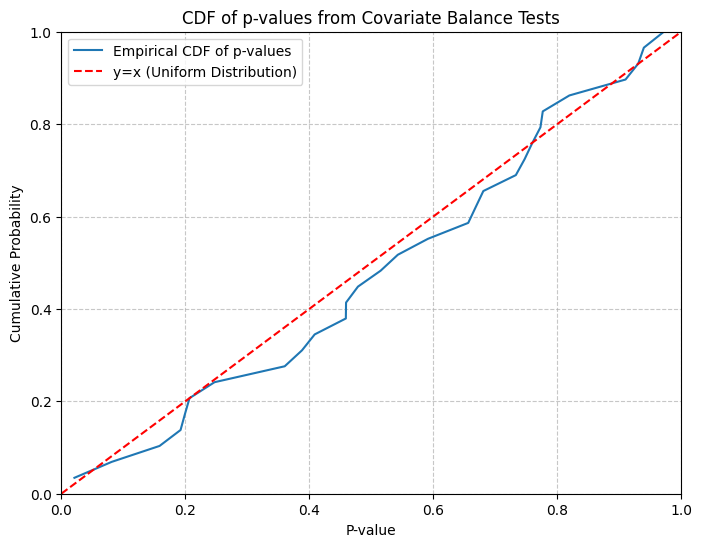

Interpretation: If covariates are perfectly balanced, the CDF of p-values should closely follow the y=x line. Deviations from this line indicate potential imbalances.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Extract all p-values from the DataFrame and flatten into a 1D array, dropping NaNs
all_p_values = p_values_df.values.flatten()
all_p_values = all_p_values[~np.isnan(all_p_values)]

# Sort the p-values in ascending order
sorted_p_values = np.sort(all_p_values)

# Calculate the empirical CDF values
# The y-axis represents the proportion of p-values less than or equal to the corresponding x-value
cdf_y = np.arange(1, len(sorted_p_values) + 1) / len(sorted_p_values)

plt.figure(figsize=(8, 6))

# Plot the CDF of the p-values
plt.plot(sorted_p_values, cdf_y, label='Empirical CDF of p-values')

# Plot the y=x line for comparison (representing a uniform distribution)
plt.plot([0, 1], [0, 1], 'r--', label='y=x (Uniform Distribution)')

plt.title('CDF of p-values from Covariate Balance Tests')
plt.xlabel('P-value')
plt.ylabel('Cumulative Probability')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.show()

print("Interpretation: If covariates are perfectly balanced, the CDF of p-values should closely follow the y=x line. Deviations from this line indicate potential imbalances.")


In [ ]:
stratum_bmi_means = df.groupby(['propensity_stratum', 'School_meal'])['BMI'].mean()
print("Stratum-wise mean BMI (treatment and control):\n", stratum_bmi_means)

stratum_bmi_means_unstacked = stratum_bmi_means.unstack()

stratum_effects = stratum_bmi_means_unstacked[1] - stratum_bmi_means_unstacked[0]
print("\nStratum-specific treatment effects (difference in means):\n", stratum_effects)

Stratum-wise mean BMI (treatment and control):
 propensity_stratum  School_meal
0                   0              19.361587
                    1              19.356667
1                   0              19.686115
                    1              20.589775
2                   0              19.653613
                    1              19.929242
3                   0              21.020467
                    1              20.666078
4                   0              22.177037
                    1              20.400413
Name: BMI, dtype: float64

Stratum-specific treatment effects (difference in means):
 propensity_stratum
0   -0.004920
1    0.903660
2    0.275629
3   -0.354389
4   -1.776624
dtype: float64


In [ ]:
stratum_sizes = df.groupby('propensity_stratum').size()
total_observations = df.shape[0]
stratum_proportions = stratum_sizes / total_observations
overall_ate = (stratum_proportions * stratum_effects).sum()
print("ATE: ",overall_ate)
stratum_bmi_variances = df.groupby(['propensity_stratum', 'School_meal'])['BMI'].var()
stratum_bmi_variances_unstacked = stratum_bmi_variances.unstack()

stratum_group_sizes_unstacked = stratum_group_sizes.unstack()


# Calculate the variance of the difference in means for each stratum
# Var(diff) = Var(mean_T) + Var(mean_C) = Var_T/n_T + Var_C/n_C
stratum_variance_of_difference = (stratum_bmi_variances_unstacked[1] / stratum_group_sizes_unstacked[1]) + \
                                 (stratum_bmi_variances_unstacked[0] / stratum_group_sizes_unstacked[0])

# Calculate the standard error of the difference in means for each stratum
stratum_se_of_difference = np.sqrt(stratum_variance_of_difference)
overall_variance = (stratum_proportions**2 * stratum_variance_of_difference).sum()
overall_variance  += (stratum_proportions  * (stratum_effects  - overall_ate) ** 2).sum()
overall_se = np.sqrt(overall_variance)

print("Overall Variance of Stratified Estimator:", overall_variance)
print("Overall Standard Error of Stratified Estimator:", overall_se)
print("t-statistics: ", overall_ate / overall_se)

ATE:  -0.19468742924649074
Overall Variance of Stratified Estimator: 0.793466229830915
Overall Standard Error of Stratified Estimator: 0.8907672141647979
t-statistics:  -0.21856151208824381


In [ ]:
#IPW
import numpy as np
from scipy import stats
def IPW(df,selected_covariates):
  # Treatment indicator (Z)
  Z = df['School_meal']
  # Outcome (Y)
  Y = df['BMI']
  final_formula_str_with_interactions = "School_meal ~ " + " + ".join(selected_covariates)

  final_logit_model_with_interactions = sm.Logit.from_formula(final_formula_str_with_interactions, data=df)
  final_logit_result_with_interactions = final_logit_model_with_interactions.fit(disp=0)

  e = final_logit_result_with_interactions.predict(df)

  weighted_outcome_treated = (Y * Z) / e


  weighted_outcome_control = (Y * (1 - Z)) / (1 - e)

  ipw_ate = np.mean(weighted_outcome_treated - weighted_outcome_control)
  return ipw_ate


IPW(df,selected_covariates)

np.float64(-1.7706214290432676)

In [ ]:
import numpy as np
from scipy import stats
def Hajek(df,selected_covariates):
  # Treatment indicator (Z)
  Z = df['School_meal']
  # Outcome (Y)
  Y = df['BMI']

  inal_formula_str_with_interactions = "School_meal ~ " + " + ".join(selected_covariates)

  final_logit_model_with_interactions = sm.Logit.from_formula(final_formula_str_with_interactions, data=df)
  final_logit_result_with_interactions = final_logit_model_with_interactions.fit(disp=0)

  e = final_logit_result_with_interactions.predict(df)

  weighted_outcome_treated = (Y * Z) / e
  weighted_indicator_treated = Z/e

  weighted_outcome_control = (Y * (1 - Z)) / (1 - e)
  weighted_indicator_control = (1-Z)/(1-e)

  hajek_est = np.sum(weighted_outcome_treated) / np.sum(weighted_indicator_treated) - np.sum(weighted_outcome_control) / np.sum(weighted_indicator_control)


  #print(f"Hajek Average Treatment Effect (ATE): {hajek_est:.4f}")
  return hajek_est

Hajek(df,selected_covariates)

np.float64(-0.3568720614697618)

In [ ]:
def bootstrap(method, df, num_resamples):
    ate_estimates = []
    for _ in range(num_resamples):
        # Create a bootstrap sample (resample with replacement)
        bootstrap_sample = df.sample(n=len(df), replace=True, random_state=None) # random_state=None for different samples each time

        # Apply the provided method to the bootstrap sample
        # Assuming the method returns (ate_estimate, variance_estimate)
        ate_estimate = method(bootstrap_sample,selected_covariates)
        ate_estimates.append(ate_estimate)

    # Convert to numpy array for easier calculations
    ate_estimates = np.array(ate_estimates)

    # Calculate empirical variance
    empirical_variance = np.var(ate_estimates, ddof=1) # ddof=1 for sample variance

    # Calculate 2.5% and 97.5% quantiles
    lower_quantile = np.percentile(ate_estimates, 2.5)
    upper_quantile = np.percentile(ate_estimates, 97.5)

    return empirical_variance, lower_quantile, upper_quantile


In [ ]:
bootstrap(IPW, df, 100)

(np.float64(0.7084159312885278),
 np.float64(-3.790927123148388),
 np.float64(-0.6288910564802496))

In [ ]:
bootstrap(Hajek, df, 100)

(np.float64(0.06831800370370457),
 np.float64(-0.9267102867604575),
 np.float64(0.1301359335882429))

# Outcome Regression

In [ ]:
combined_covariates = list(set(covariates_for_diff + selected_covariates))
combined_covariates.sort()
print(combined_covariates)

In [ ]:
import statsmodels.api as sm

# Define the dependent variable (outcome)
y_outcome = df['BMI']

# The 'selected_covariates' list already contains the main effects and the significant interaction terms.
# Construct the formula string for the OLS model, which includes all main effects and interaction terms.
formula_for_outcome_regression = "BMI ~ " + " + ".join(combined_covariates)

# --- Regression for the Control Group (School_meal = 0) ---
df_control = df[df['School_meal'] == 0].copy()

# Fit the linear regression model for the control group using the formula
outcome_model_control = sm.OLS.from_formula(formula_for_outcome_regression, data=df_control)
outcome_results_control = outcome_model_control.fit()

print("\n--- Outcome Regression Model Summary for CONTROL Group (School_meal = 0) ---")
print(outcome_results_control.summary())

# --- Regression for the Treatment Group (School_meal = 1) ---
df_treated = df[df['School_meal'] == 1].copy()

# Fit the linear regression model for the treatment group using the formula
outcome_model_treated = sm.OLS.from_formula(formula_for_outcome_regression, data=df_treated)
outcome_results_treated = outcome_model_treated.fit()

print("\n--- Outcome Regression Model Summary for TREATMENT Group (School_meal = 1) ---")
print(outcome_results_treated.summary())


In [ ]:
X_confounders = df[covariates_for_diff]
X_confounders = sm.add_constant(X_confounders)


mu_hat_1 = outcome_results_treated.predict(X_confounders)

mu_hat_0 = outcome_results_control.predict(X_confounders)
print(np.mean(mu_hat_1 - mu_hat_0 ))

0.03349835863372848


In [ ]:

import statsmodels.api as sm
import numpy as np
from scipy import stats



    # Define outcome and treatment variables
Y = df['BMI']
Z = df['School_meal']
e = propensity_scores
eif = (mu_hat_1 - mu_hat_0) + \
        (Z * (Y - mu_hat_1)) / e - \
        ((1 - Z) * (Y - mu_hat_0)) / (1 - e)

# The AIPW ATE is the mean of these individual influence values
ate_aipw = np.mean(eif)
se_aipw_ate = np.sqrt(np.var(eif, ddof=1) / len(eif))
print(f"AIPW ATE Estimate: {ate_aipw:.4f}")
print(f"AIPW Standard Error: {se_aipw_ate:.4f}")



AIPW ATE Estimate: -0.0992
AIPW Standard Error: 0.2471


In [ ]:
!pip install cvxpy
!pip install cvxopt

In [ ]:

import cvxpy as cp
import numpy as np
import pandas as pd

def CBE(df, treatment_col='School_meal', outcome_col='BMI', covariate_cols=covariates_for_diff):
    # 1. Extract data
    T = df[treatment_col].values
    Y = df[outcome_col].values
    X = df[covariate_cols].values

    # 2. Separate data into treated and control groups
    X1 = X[T == 1]
    Y1 = Y[T == 1]
    N1 = len(X1)

    X0 = X[T == 0]
    Y0 = Y[T == 0]
    N0 = len(X0)
    N = N1+N0

    # 3. Compute overall means of the covariates
    # Reshape X to be (n_samples, n_covariates) if it's not already
    overall_covariate_means = np.mean(X, axis=0)

    # 4. Define cvxpy variables for weights
    w1 = cp.Variable(N1)  # Weights for treated group
    w0 = cp.Variable(N0)  # Weights for control group

    # 5. Set the optimization objective: minimize the sum of squared weights
    objective = cp.Minimize(cp.sum_squares(w1) + cp.sum_squares(w0))

    # 6. Define constraints
    constraints = [
        # Constraints for treated group (w1)
        cp.sum(w1) == N,               # Sum of weights equals N1
        w1 >= 0,                        # Weights must be non-negative
        X1.T @ w1 == N * overall_covariate_means,  # Covariate balancing

        # Constraints for control group (w0)
        cp.sum(w0) == N,               # Sum of weights equals N0
        w0 >= 0,                        # Weights must be non-negative
        X0.T @ w0 == N * overall_covariate_means   # Covariate balancing
    ]

    # 7. Create and solve the problem
    problem = cp.Problem(objective, constraints)
    try:
        problem.solve(verbose=False)

        # 8. Check if the problem was solved optimally
        if problem.status in [cp.OPTIMAL, cp.OPTIMAL_INACCURATE]:
            weights1 = w1.value
            weights0 = w0.value

            # 9. Calculate ATE
            # Ensure no division by zero for N1/N0, though unlikely with optimal solution
            mean_outcome_treated_weighted = np.sum(weights1 * Y1) / N  if N1 > 0 else 0
            mean_outcome_control_weighted = np.sum(weights0 * Y0) / N if N0 > 0 else 0
            ate_cbe = mean_outcome_treated_weighted - mean_outcome_control_weighted

            #ate_var = np.sum((weights1 * Y1 - ate_cbe) ** 2) + np.sum( (weights0 * ate_cbe + Y0) ** 2)
            #ate_var = ate_var / N ** 2

            # Return ATE and NaN for variance as per instructions
            return ate_cbe
        else:
            # If not optimal, return NaN for ATE and variance
            print(f"CBE Warning: Problem not solved optimally. Status: {problem.status}")
            return np.nan, np.nan
    except Exception as e:
        print(f"CBE Error during problem solving: {e}")
        return np.nan, np.nan


In [ ]:
CBE(df)

np.float64(-0.01700887400366824)

In [ ]:
import pandas as pd

# Explicitly create interaction columns in the DataFrame
for term in selected_covariates:
    if ':' in term:
        factors = term.split(':')
        if len(factors) == 2:
            df[term] = df[factors[0]] * df[factors[1]]

# Now call CBE with the DataFrame that has the interaction terms as columns
CBE(df, 'School_meal', 'BMI', combined_covariates)

(np.float64(0.032724629072607314),
 [array([1.44574827, 2.38337948, 3.61996558, ..., 1.75865044, 2.48492069,
         2.14148694]),
  array([0.8735608 , 3.97987648, 3.39320659, ..., 2.26214835, 0.73572071,
         1.06718868])])

Conclusion: it is more likely that school-meal has a negative effect on BMI, but not statistically significant.